# Lab 09 — Symbolic Policy Distillation

**Goal:** distill the symbolic Wordle expert's *policy distribution* into `Qwen/Qwen3-0.6B`.

Lab 07 used hard targets:

```text
state → one expert word
```

Lab 09 uses soft targets:

```text
state → distribution over candidate guesses
```

For a Wordle state, the symbolic expert can score every surviving candidate by expected information gain (entropy). Instead of throwing away all but the best action, we convert those scores into a teacher distribution and train Qwen to approximate it.

That is the core distillation idea: learn the teacher's relative preferences, not merely its top-1 answer.

## 9.1 Distillation objective

Suppose the symbolic expert scores a state like this:

```text
FLOAT   H=4.86
PLANT   H=4.21
SLANT   H=3.97
BLANK   H=3.62
```

Hard-label SFT keeps only `FLOAT`.

Policy distillation keeps a softened distribution, for example:

```text
FLOAT   0.40
PLANT   0.24
SLANT   0.18
BLANK   0.10
```

We combine:

```text
hard action loss
+
KL divergence between teacher and student policy distributions
```

This follows the standard knowledge-distillation pattern of mixing hard supervision with temperature-softened teacher targets.

## 9.2 Shared action space

The symbolic expert and Qwen do not need compatible token vocabularies.

We define the shared action space as:

```text
the surviving Wordle candidate words for the current state
```

Teacher:

```text
entropy score for each candidate word
```

Student:

```text
whole-word log-likelihood for each same candidate word
```

Then both distributions are defined over the exact same Wordle actions.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import hashlib
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoModelForCausalLM, AutoTokenizer

from tiny_wordle.game import Turn, score_string
from tiny_wordle.expert import EntropyExpert

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)
print('PyTorch:', torch.__version__)

device: mps
PyTorch: 2.13.0


## 9.3 Load the symbolic expert

Reuse the exact answer lexicon and pattern matrix from Lab 05.

In [2]:
DATA_DIR = Path('../data')

ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / 'wordle-answers-original.txt').read_text().splitlines()
    if line.strip()
]

PATTERNS = np.load(DATA_DIR / 'wordle-patterns-original-2315.npy')

assert len(ANSWERS) == 2315
assert PATTERNS.shape == (2315, 2315)

expert = EntropyExpert(ANSWERS, PATTERNS)
WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print('answers:', len(ANSWERS))
print('pattern matrix:', PATTERNS.shape, PATTERNS.dtype)

answers: 2315
pattern matrix: (2315, 2315) uint8


## 9.4 Reuse the Lab 06 answer split

Keep train/dev/test boundaries consistent with the earlier labs.

In [3]:
DEV_FIXED = {'PLANT'}

TEST_FIXED = {
    'SHORE','MIGHT','BRICK','GHOST','KNIFE',
    'DOUBT','FLING','ROUND','CHAMP','WASTE',
    'BLIND','POINT','SLATE','CRANE','APPLE',
    'SHEEP','BANAL','ALLEY','AUDIO',
}

def stable_bucket(word: str) -> int:
    digest = hashlib.sha256(word.encode('utf-8')).digest()
    return int.from_bytes(digest[:8], 'big') % 1000

def answer_split(answer: str) -> str:
    if answer in TEST_FIXED:
        return 'test'
    if answer in DEV_FIXED:
        return 'dev'
    return 'dev' if stable_bucket(answer) < 100 else 'train'

print({split: sum(answer_split(w)==split for w in ANSWERS) for split in ['train','dev','test']})

{'train': 2065, 'dev': 231, 'test': 19}


## 9.5 Collect expert policy states

A policy state stores the observable history and exact surviving candidate set before the teacher acts.

In [4]:
@dataclass
class PolicyState:
    answer: str
    split: str
    turn: int
    history: list[Turn]
    candidate_indices: list[int]

def collect_policy_states(answer: str, max_turns: int = 6):
    candidate_indices = ALL_INDICES.copy()
    history: list[Turn] = []
    states: list[PolicyState] = []
    solved = False

    for turn in range(1, max_turns + 1):
        states.append(PolicyState(
            answer=answer,
            split=answer_split(answer),
            turn=turn,
            history=list(history),
            candidate_indices=candidate_indices.tolist(),
        ))

        guess_idx = expert.choose(candidate_indices)
        guess = ANSWERS[guess_idx]
        feedback = score_string(answer, guess)
        history.append(Turn(guess=guess, feedback=feedback))

        if feedback == 'GGGGG':
            solved = True
            break

        candidate_indices = expert.update(candidate_indices, guess_idx, feedback)
        if len(candidate_indices) == 0:
            raise RuntimeError(f'candidate set empty for {answer}')

    return states, solved

all_states=[]
solved_by_answer={}
for answer in ANSWERS:
    states, solved = collect_policy_states(answer)
    all_states.extend(states)
    solved_by_answer[answer] = solved

print('policy states:', len(all_states))
print('solved expert trajectories:', sum(solved_by_answer.values()))
print('failed expert trajectories:', sum(not x for x in solved_by_answer.values()))

policy states: 8319
solved expert trajectories: 2304
failed expert trajectories: 11


## 9.6 Choose a practical distillation subset

Scoring every candidate through Qwen is more expensive than ordinary SFT.

For the first run:

- train split only;
- skip turn 1;
- only solved teacher trajectories;
- at most 32 surviving candidates;
- sample up to 3,000 states.

In [5]:
MAX_CANDIDATES = 32
DISTILL_STATES = 3000

eligible_states = [
    s for s in all_states
    if s.split == 'train'
    and s.turn > 1
    and 2 <= len(s.candidate_indices) <= MAX_CANDIDATES
    and solved_by_answer[s.answer]
]

print('eligible policy states:', len(eligible_states))

rng = random.Random(SEED)
distill_states = rng.sample(eligible_states, min(DISTILL_STATES, len(eligible_states)))
print('selected distillation states:', len(distill_states))

eligible policy states: 2698
selected distillation states: 2698


In [6]:
assert len(distill_states) == 2698

assert all(
    2 <= len(s.candidate_indices) <= MAX_CANDIDATES
    for s in distill_states
)

print("Selected states all have 2..32 candidates.")

Selected states all have 2..32 candidates.


## 9.7 Gameplay-format prompt

Use a deployment-like prompt rather than the Lab 06 `Task: NEXT_GUESS` wrapper.

In [7]:
DISTILL_SYSTEM = """Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched
"""

def format_history(history: list[Turn]) -> str:
    if not history:
        return 'No guesses have been made yet.'
    return '\n'.join(
        f"{' '.join(t.guess)} -> {' '.join(t.feedback)}"
        for t in history
    )

def build_policy_prompt(state: PolicyState) -> str:
    return DISTILL_SYSTEM + '\nGame history:\n' + format_history(state.history)

print(build_policy_prompt(distill_states[0]))

Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched

Game history:
R A I S E -> B B G B G
U T I L E -> B B G G G


## 9.8 Teacher soft policy

Teacher score = entropy of each surviving candidate guess.

Convert entropy scores to probabilities with softmax temperature.

In [8]:
TEACHER_TEMPERATURE = 0.5

def teacher_entropy_scores(candidate_indices: list[int]) -> np.ndarray:
    arr = np.asarray(candidate_indices, dtype=np.int32)
    return np.asarray([
        expert.entropy(int(i), arr)
        for i in arr
    ], dtype=np.float32)

def teacher_distribution(
    candidate_indices: list[int],
    temperature: float = TEACHER_TEMPERATURE,
) -> np.ndarray:
    scores = teacher_entropy_scores(candidate_indices)
    scaled = scores / temperature
    scaled -= scaled.max()
    probs = np.exp(scaled)
    probs /= probs.sum()
    return probs.astype(np.float32)

state = next(
    s
    for s in distill_states
    if 5 <= len(s.candidate_indices) <= 20
)

print("candidate count:", len(state.candidate_indices))

words = [
    ANSWERS[i]
    for i in state.candidate_indices
]

scores = teacher_entropy_scores(
    state.candidate_indices
)

probs = teacher_distribution(
    state.candidate_indices
)

preview = (
    pd.DataFrame({
        "word": words,
        "entropy": scores,
        "teacher_prob": probs,
    })
    .sort_values(
        "teacher_prob",
        ascending=False,
    )
)

preview.head(10)

candidate count: 12


,word,entropy,teacher_prob
2,ALIGN,3.084963,0.185540
8,AXION,3.084963,0.185540
5,AVIAN,2.855389,0.117228
6,AXIAL,2.855389,0.117228
10,ILIAC,2.617492,0.072845
0,AGING,2.584963,0.068256
4,APING,2.584963,0.068256
7,AXIOM,2.450826,0.052195
9,CHINA,2.355389,0.043126
11,VOILA,2.355389,0.043126


## 9.9 Temperature experiment

Lower temperature makes the policy more top-1-like. Higher temperature preserves more relative preference information.

In [9]:
for T in [0.25, 0.5, 1.0, 2.0]:
    p = teacher_distribution(state.candidate_indices, temperature=T)
    top = sorted(zip(words,p), key=lambda x:x[1], reverse=True)[:5]
    print('\nT =', T)
    for word, prob in top:
        print(f'{word}: {prob:.3f}')


T = 0.25
ALIGN: 0.289
AXION: 0.289
AVIAN: 0.116
AXIAL: 0.116
ILIAC: 0.045

T = 0.5
ALIGN: 0.186
AXION: 0.186
AVIAN: 0.117
AXIAL: 0.117
ILIAC: 0.073

T = 1.0
ALIGN: 0.132
AXION: 0.132
AVIAN: 0.105
AXIAL: 0.105
ILIAC: 0.083

T = 2.0
ALIGN: 0.107
AXION: 0.107
AVIAN: 0.095
AXIAL: 0.095
ILIAC: 0.084


## 9.10 Persist soft targets

In [10]:
DISTILL_DIR = DATA_DIR / 'generated' / 'distillation'
DISTILL_DIR.mkdir(parents=True, exist_ok=True)

records=[]
for s in distill_states:
    candidates=[ANSWERS[i] for i in s.candidate_indices]
    probs=teacher_distribution(s.candidate_indices)
    records.append({
        'answer':s.answer,
        'turn':s.turn,
        'candidate_count':len(s.candidate_indices),
        'prompt':build_policy_prompt(s),
        'candidates':candidates,
        'teacher_probs':probs.tolist(),
    })

distill_df=pd.DataFrame(records)
print(distill_df.shape)
display(distill_df.head())

SOFT_DATA_PATH = DISTILL_DIR / 'symbolic-policy-soft-targets.jsonl'
distill_df.to_json(SOFT_DATA_PATH, orient='records', lines=True, force_ascii=False)
print(SOFT_DATA_PATH)

(2698, 6)


,answer,turn,candidate_count,prompt,candidates,teacher_probs
0,WHILE,3,2,Play Wordle.\n\nReturn exactly one uppercase f...,"[EXILE, WHILE]","[0.5, 0.5]"
1,COWER,3,26,Play Wordle.\n\nReturn exactly one uppercase f...,"[BLUER, BOXER, BUYER, CORER, COVER, COWER, CYB...","[0.028926940634846687, 0.017936723306775093, 0..."
2,AXIAL,2,12,Play Wordle.\n\nReturn exactly one uppercase f...,"[AGING, ALIBI, ALIGN, AMITY, APING, AVIAN, AXI...","[0.06825628131628036, 0.038027387112379074, 0...."
3,JELLY,3,9,Play Wordle.\n\nReturn exactly one uppercase f...,"[CELLO, FELON, HELLO, JELLY, LEGGY, LEMON, MEL...","[0.19832676649093628, 0.12716320157051086, 0.1..."
4,GUILE,2,23,Play Wordle.\n\nReturn exactly one uppercase f...,"[CHIDE, CHIME, ELIDE, ELITE, EXILE, GLIDE, GUI...","[0.029207317158579826, 0.009807514026761055, 0..."


../data/generated/distillation/symbolic-policy-soft-targets.jsonl


In [11]:
print(distill_df["candidate_count"].describe())

assert distill_df["candidate_count"].min() >= 2
assert distill_df["candidate_count"].max() <= 32

count    2698.000000
mean        8.565604
std         7.889365
min         2.000000
25%         3.000000
50%         5.000000
75%        13.000000
max        29.000000
Name: candidate_count, dtype: float64


## 9.11 Load a fresh Qwen student

In [12]:
MODEL_ID='Qwen/Qwen3-0.6B'
tokenizer=AutoTokenizer.from_pretrained(MODEL_ID)
student=AutoModelForCausalLM.from_pretrained(MODEL_ID,dtype=torch.float32).to(device)
print(type(student).__name__)
print('trainable parameters:', f"{sum(p.numel() for p in student.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen3ForCausalLM
trainable parameters: 596,049,920


## 9.12 Score whole-word actions with Qwen

For each candidate action:

```text
log P(word | prompt)
  = sum of token log-probabilities for that whole word + EOS
```

This yields one student score per candidate word, even though different words tokenize differently.

In [13]:
def render_student_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{'role':'user','content':prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def score_candidate_actions(model, prompt: str, candidates: list[str]) -> torch.Tensor:
    prompt_text = render_student_prompt(prompt)
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)['input_ids']

    sequences=[]; masks=[]
    for candidate in candidates:
        candidate_ids = tokenizer(candidate + tokenizer.eos_token, add_special_tokens=False)['input_ids']
        sequences.append(prompt_ids + candidate_ids)
        masks.append([0]*len(prompt_ids) + [1]*len(candidate_ids))

    max_len=max(len(x) for x in sequences)
    pad_id=tokenizer.pad_token_id or tokenizer.eos_token_id
    input_rows=[]; attention_rows=[]; mask_rows=[]
    for ids,mask in zip(sequences,masks):
        pad=max_len-len(ids)
        input_rows.append(ids+[pad_id]*pad)
        attention_rows.append([1]*len(ids)+[0]*pad)
        mask_rows.append(mask+[0]*pad)

    input_ids=torch.tensor(input_rows,dtype=torch.long,device=device)
    attention_mask=torch.tensor(attention_rows,dtype=torch.long,device=device)
    target_mask=torch.tensor(mask_rows,dtype=torch.bool,device=device)

    # Project only positions that predict candidate tokens. Computing prompt
    # logits would create a very large candidates x prompt x vocabulary tensor.
    logit_positions=torch.arange(len(prompt_ids)-1,max_len-1,device=device)
    logits=model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        logits_to_keep=logit_positions,
        use_cache=False,
    ).logits
    targets=input_ids[:,len(prompt_ids):]
    effective_mask=target_mask[:,len(prompt_ids):]

    token_log_probs=F.log_softmax(logits,dim=-1).gather(-1,targets.unsqueeze(-1)).squeeze(-1)
    return (token_log_probs*effective_mask).sum(dim=-1)

In [14]:
sample_row=distill_df.iloc[0]
with torch.no_grad():
    s_scores=score_candidate_actions(student,sample_row['prompt'],sample_row['candidates'])
student_probs=torch.softmax(s_scores/TEACHER_TEMPERATURE,dim=-1).cpu().numpy()
compare=pd.DataFrame({
    'word':sample_row['candidates'],
    'teacher_prob':sample_row['teacher_probs'],
    'student_prob':student_probs,
}).sort_values('teacher_prob',ascending=False)
display(compare.head(10))

,word,teacher_prob,student_prob
0,EXILE,0.5,0.999995
1,WHILE,0.5,0.000005


## 9.13 Distillation loss

Combine:

```text
75% soft KL loss
25% hard top-action loss
```

The soft term teaches relative preferences. The hard term preserves the teacher's best action.

In [15]:
ALPHA_HARD=0.25
ALPHA_SOFT=0.75
DISTILL_T=TEACHER_TEMPERATURE

def distillation_loss_for_state(model,row):
    action_scores=score_candidate_actions(model,row['prompt'],row['candidates'])
    teacher_probs=torch.tensor(row['teacher_probs'],dtype=torch.float32,device=device)
    teacher_probs=teacher_probs/teacher_probs.sum()

    student_log_probs=F.log_softmax(action_scores/DISTILL_T,dim=-1)
    soft_loss=F.kl_div(student_log_probs,teacher_probs,reduction='batchmean')*(DISTILL_T**2)

    hard_index=int(torch.argmax(teacher_probs).item())
    hard_target=torch.tensor([hard_index],dtype=torch.long,device=device)
    hard_loss=F.cross_entropy(action_scores.unsqueeze(0),hard_target)

    total=ALPHA_SOFT*soft_loss + ALPHA_HARD*hard_loss
    return total, soft_loss.detach(), hard_loss.detach()

student.train()

row = distill_df[
    distill_df["candidate_count"].between(5, 20)
].iloc[0]

print("candidate count:", row["candidate_count"])
print("candidates:", row["candidates"])
print("teacher probs:", row["teacher_probs"])

print(distill_df["candidate_count"].value_counts().sort_index())
print()
print(distill_df["candidate_count"].describe())

loss, soft_loss, hard_loss = (
    distillation_loss_for_state(
        student,
        row,
    )
)

print("total loss:", float(loss.detach().cpu()))
print("soft KL loss:", float(soft_loss.cpu()))
print("hard action loss:", float(hard_loss.cpu()))

candidate count: 12
candidates: ['AGING', 'ALIBI', 'ALIGN', 'AMITY', 'APING', 'AVIAN', 'AXIAL', 'AXIOM', 'AXION', 'CHINA', 'ILIAC', 'VOILA']
teacher probs: [0.06825628131628036, 0.038027387112379074, 0.18553981184959412, 0.008632556535303593, 0.06825628131628036, 0.11722808331251144, 0.11722808331251144, 0.0521954670548439, 0.18553981184959412, 0.043125804513692856, 0.07284465432167053, 0.043125804513692856]
candidate_count
2     634
3     374
4     265
5     181
6     171
7      99
8     108
9      71
10     15
11     18
12     53
13     72
14     36
15     41
16     43
17     48
18     35
19     18
20     87
21     38
22     19
23     38
24     24
25     25
26    110
28     48
29     27
Name: count, dtype: int64

count    2698.000000
mean        8.565604
std         7.889365
min         2.000000
25%         3.000000
50%         5.000000
75%        13.000000
max        29.000000
Name: candidate_count, dtype: float64
total loss: 0.38346773386001587
soft KL loss: 0.12894295156002045
har

## 9.14 Train one epoch

One state = one optimizer step because each state has a different candidate count.

This is deliberately more expensive per example than ordinary SFT, so we keep the first run to 3,000 states.

In [16]:
LEARNING_RATE=1e-5
WEIGHT_DECAY=0.01
EPOCHS=1

optimizer=AdamW(student.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
total_steps=len(distill_df)*EPOCHS
warmup_steps=max(1,int(total_steps*0.05))

def lr_multiplier(step:int)->float:
    if step<warmup_steps:
        return (step+1)/warmup_steps
    progress=(step-warmup_steps)/max(1,total_steps-warmup_steps)
    return 0.5*(1+math.cos(math.pi*progress))

scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda=lr_multiplier)
print('total steps:', total_steps)
print('warmup steps:', warmup_steps)

total steps: 2698
warmup steps: 134


In [17]:
CHECKPOINT_DIR=Path('../checkpoints/qwen3-0.6b-symbolic-policy-distilled')
CHECKPOINT_DIR.mkdir(parents=True,exist_ok=True)

order=list(range(len(distill_df)))
random.Random(SEED).shuffle(order)
history=[]
student.train()
start=time.perf_counter()

for step_number,row_index in enumerate(order,1):
    row=distill_df.iloc[row_index]
    optimizer.zero_grad(set_to_none=True)
    total_loss,soft_loss,hard_loss=distillation_loss_for_state(student,row)
    total_loss.backward()
    grad_norm=torch.nn.utils.clip_grad_norm_(student.parameters(),1.0)
    optimizer.step(); scheduler.step()

    rec={
        'step':step_number,
        'total_loss':float(total_loss.detach().cpu()),
        'soft_loss':float(soft_loss.cpu()),
        'hard_loss':float(hard_loss.cpu()),
        'grad_norm':float(grad_norm),
        'lr':scheduler.get_last_lr()[0],
    }
    if device.type=='mps':
        rec['mps_allocated_gib']=torch.mps.current_allocated_memory()/2**30
        rec['mps_driver_gib']=torch.mps.driver_allocated_memory()/2**30
    history.append(rec)

    if step_number==1 or step_number%50==0 or step_number==total_steps:
        elapsed=time.perf_counter()-start
        print(
            f"step {step_number:4d}/{total_steps} | "
            f"total {rec['total_loss']:.4f} | "
            f"soft {rec['soft_loss']:.4f} | "
            f"hard {rec['hard_loss']:.4f} | "
            f"grad {rec['grad_norm']:.3f} | "
            f"lr {rec['lr']:.2e} | {elapsed:.1f}s"
            +(
                f" | MPS tensors {rec['mps_allocated_gib']:.2f} GiB, "
                f"driver {rec['mps_driver_gib']:.2f} GiB"
                if device.type=='mps' else ''
            )
        )
        
    if step_number % 100 == 0:
        recent = pd.DataFrame(history[-100:])
    
        print(
            "  rolling100 | "
            f"total {recent['total_loss'].mean():.4f} | "
            f"soft {recent['soft_loss'].mean():.4f} | "
            f"hard {recent['hard_loss'].mean():.4f}"
        )

elapsed=time.perf_counter()-start
student.save_pretrained(CHECKPOINT_DIR,safe_serialization=True)
tokenizer.save_pretrained(CHECKPOINT_DIR)
print('training seconds:', elapsed)
print('saved:', CHECKPOINT_DIR)

step    1/2698 | total 0.7342 | soft 0.9770 | hard 0.0059 | grad 422.044 | lr 1.49e-07 | 1.5s | MPS tensors 13.63 GiB, driver 17.09 GiB
step   50/2698 | total 2.0880 | soft 0.0445 | hard 8.2183 | grad 285.117 | lr 3.81e-06 | 72.7s | MPS tensors 13.75 GiB, driver 33.75 GiB
step  100/2698 | total 0.7552 | soft 0.0596 | hard 2.8422 | grad 59.867 | lr 7.54e-06 | 144.0s | MPS tensors 13.75 GiB, driver 34.54 GiB
step  150/2698 | total 0.6699 | soft 0.2302 | hard 1.9891 | grad 63.886 | lr 1.00e-05 | 214.5s | MPS tensors 13.75 GiB, driver 34.53 GiB
step  200/2698 | total 0.3933 | soft 0.0028 | hard 1.5651 | grad 40.834 | lr 9.98e-06 | 286.9s | MPS tensors 13.67 GiB, driver 34.53 GiB
step  250/2698 | total 0.4926 | soft 0.0391 | hard 1.8531 | grad 54.028 | lr 9.95e-06 | 357.7s | MPS tensors 13.75 GiB, driver 34.53 GiB
step  300/2698 | total 0.1947 | soft 0.0913 | hard 0.5051 | grad 11.059 | lr 9.90e-06 | 430.6s | MPS tensors 13.76 GiB, driver 34.53 GiB
step  350/2698 | total 0.3789 | soft 0.104

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

training seconds: 3805.89466225
saved: ../checkpoints/qwen3-0.6b-symbolic-policy-distilled


## 9.15 Plot losses

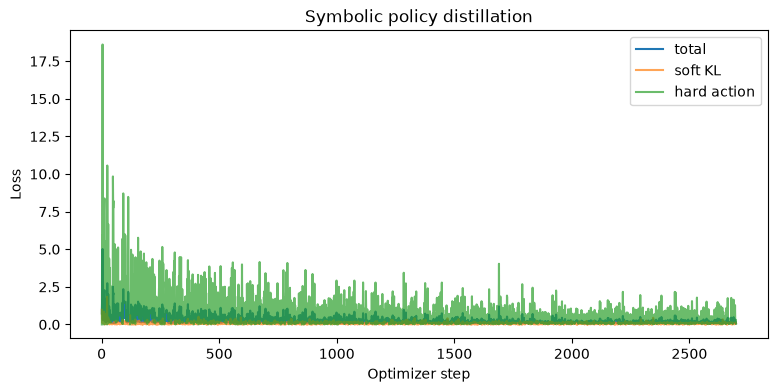

In [18]:
history_df=pd.DataFrame(history)
plt.figure(figsize=(9,4))
plt.plot(history_df['step'],history_df['total_loss'],label='total')
plt.plot(history_df['step'],history_df['soft_loss'],label='soft KL',alpha=0.7)
plt.plot(history_df['step'],history_df['hard_loss'],label='hard action',alpha=0.7)
plt.xlabel('Optimizer step'); plt.ylabel('Loss'); plt.title('Symbolic policy distillation'); plt.legend(); plt.show()

## 9.16 Evaluate policy agreement on held-out dev states

For each dev state:

- teacher top action;
- student top action over the same candidates;
- top-1 agreement;
- KL divergence.

In [19]:
dev_states=[
    s for s in all_states
    if s.split=='dev'
    and s.turn>1
    and len(s.candidate_indices)<=MAX_CANDIDATES
    and solved_by_answer[s.answer]
]
DEV_EVAL_STATES=min(300,len(dev_states))
dev_eval_states=random.Random(SEED).sample(dev_states,DEV_EVAL_STATES)
print('dev policy states:', len(dev_eval_states))

dev policy states: 300


In [20]:
student.eval()
policy_records=[]
with torch.no_grad():
    for i,s in enumerate(dev_eval_states,1):
        candidates=[ANSWERS[idx] for idx in s.candidate_indices]
        t_probs_np=teacher_distribution(s.candidate_indices)
        s_scores=score_candidate_actions(student,build_policy_prompt(s),candidates)
        s_log_probs=F.log_softmax(s_scores/DISTILL_T,dim=-1)
        s_probs=s_log_probs.exp().cpu().numpy()

        teacher_top=int(np.argmax(t_probs_np))
        student_top=int(np.argmax(s_probs))
        kl=F.kl_div(
            torch.tensor(s_log_probs.cpu().numpy(),dtype=torch.float32),
            torch.tensor(t_probs_np,dtype=torch.float32),
            reduction='batchmean',
        ).item()

        policy_records.append({
            'answer':s.answer,
            'turn':s.turn,
            'candidate_count':len(s.candidate_indices),
            'teacher_word':candidates[teacher_top],
            'student_word':candidates[student_top],
            'top1_match':teacher_top==student_top,
            'kl':kl,
        })
        if i%50==0:
            print(f'{i}/{len(dev_eval_states)}')

policy_df=pd.DataFrame(policy_records)
print('teacher top-1 agreement:', f"{policy_df['top1_match'].mean():.1%}")
print('mean teacher→student KL:', policy_df['kl'].mean())

50/300
100/300
150/300
200/300
250/300
300/300
teacher top-1 agreement: 92.7%
mean teacher→student KL: 0.18622557943686843


## 9.17 Agreement by candidate count

In [21]:
def candidate_bucket(n:int)->str:
    if n<=2: return '1-2'
    if n<=5: return '3-5'
    if n<=10: return '6-10'
    return '11-32'

policy_df['bucket']=policy_df['candidate_count'].map(candidate_bucket)
print(policy_df.groupby('bucket').agg(
    states=('top1_match','size'),
    top1=('top1_match','mean'),
    mean_kl=('kl','mean'),
))

        states      top1   mean_kl
bucket                            
1-2        161  0.888199  0.077463
11-32       52  1.000000  0.358457
3-5         58  0.931034  0.261962
6-10        29  1.000000  0.329744


## 9.18 Compare Labs 07–09

| Lab | Teacher signal | Student objective |
|---|---|---|
| 07 | symbolic top action | next-token cross entropy |
| 08 | symbolic top action | next-token CE through LoRA |
| 09 | symbolic full action distribution | hard action + KL distillation |

The question in this lab is not merely whether the student copies the teacher's winner. It is whether the student learns the teacher's *relative policy structure*.

## 9.19 Optional frozen Lab 04 gameplay benchmark

Point Lab 04 at:

```text
../checkpoints/qwen3-0.6b-symbolic-policy-distilled
```

Keep the benchmark frozen and record:

```text
solve rate
history consistency
repeat guesses
valid output rate
```

Do not tune Wordle further here. We are comparing training techniques.

# Lab 09 checkpoint

Send me:

1. policy state count;
2. eligible and selected state counts;
3. one teacher distribution preview;
4. temperature comparison;
5. one-state total/soft/hard loss;
6. training time and loss trend;
7. teacher top-1 agreement on dev;
8. mean teacher→student KL;
9. agreement by candidate-count bucket;
10. optional Lab 04 gameplay result.

After this, we move to reinforcement learning.